In [85]:
import pandas as pd

# Load the CSV
df = pd.read_csv('benchmark_milestones.csv')
cube_dfs_list = [group for _, group in df.groupby('Cube')]



,Cube,Milestone,Time(s),DeltaRAM(MB)
0,cube1_256x256x256_data.fits_256x256x256,Load initiated,0.001,0.00
1,cube1_256x256x256_data.fits_256x256x256,Update_0,0.008,0.00
2,cube1_256x256x256_data.fits_256x256x256,Update_1,0.012,0.00
3,cube1_256x256x256_data.fits_256x256x256,Update_2,0.013,0.00
4,cube1_256x256x256_data.fits_256x256x256,Update_3,0.014,0.00
...,...,...,...,...
228,cube1_256x256x256_data.fits_256x256x256,Textures sent to GPU,0.367,513.01
229,cube1_256x256x256_data.fits_256x256x256,Update_15,0.370,513.01
230,cube1_256x256x256_data.fits_256x256x256,Mask features generated,0.385,537.95
231,cube1_256x256x256_data.fits_256x256x256,Update_16,0.387,537.95


In [86]:
merged_dfs = []
for cube_df in cube_dfs_list:
    merged_df = cube_df.groupby(['Cube', 'Milestone'], as_index=False).mean(numeric_only=True)
    merged_df = merged_df.sort_values(by='Time(s)').reset_index(drop=True)
    merged_dfs.append(merged_df)


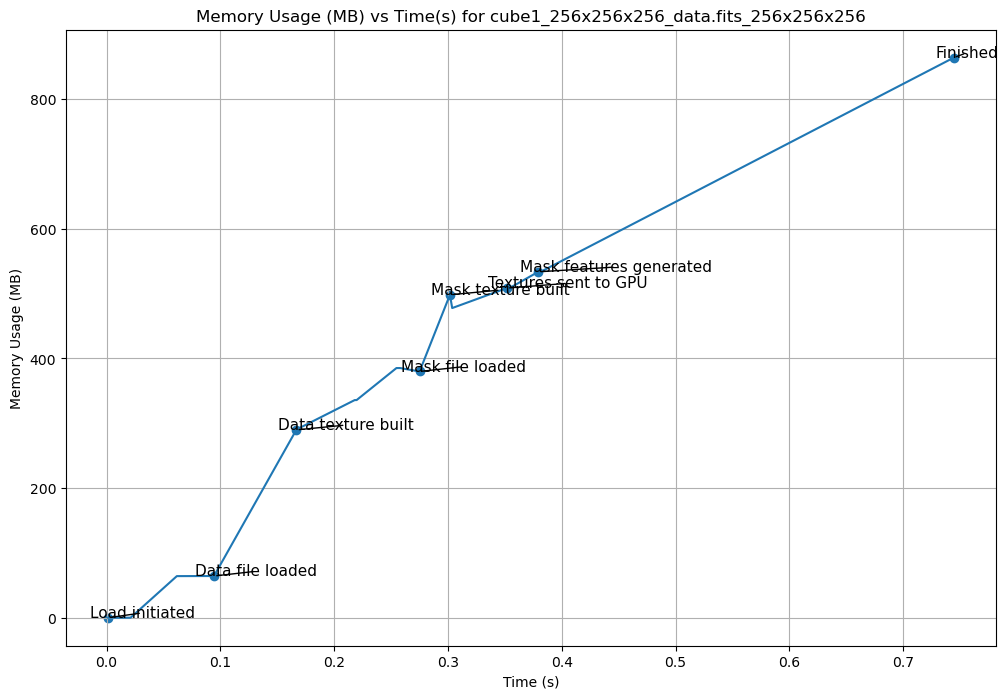

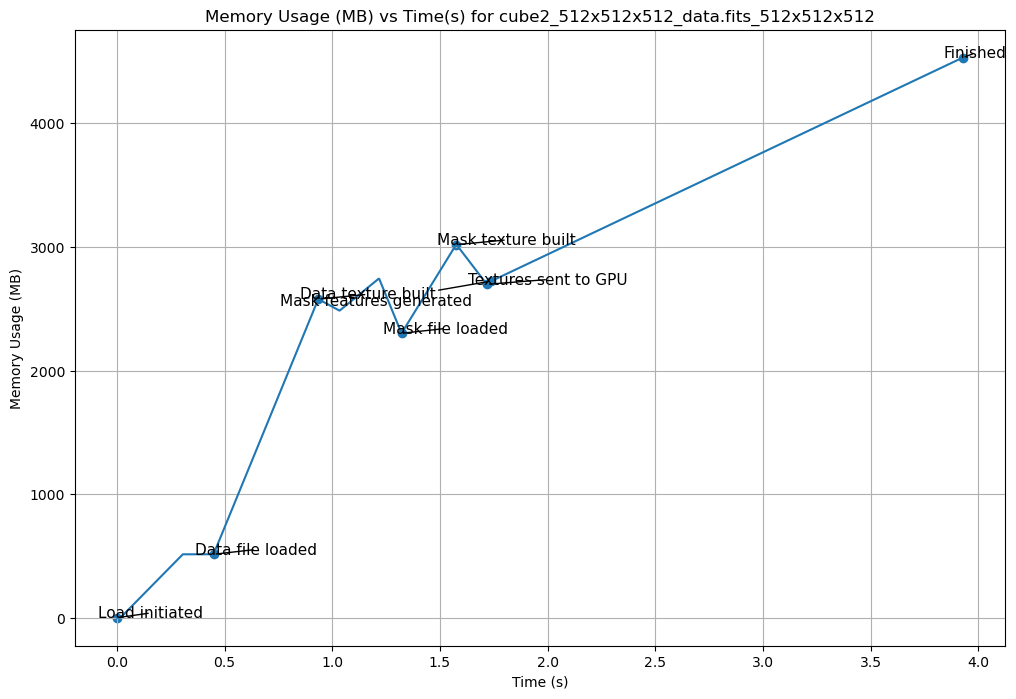

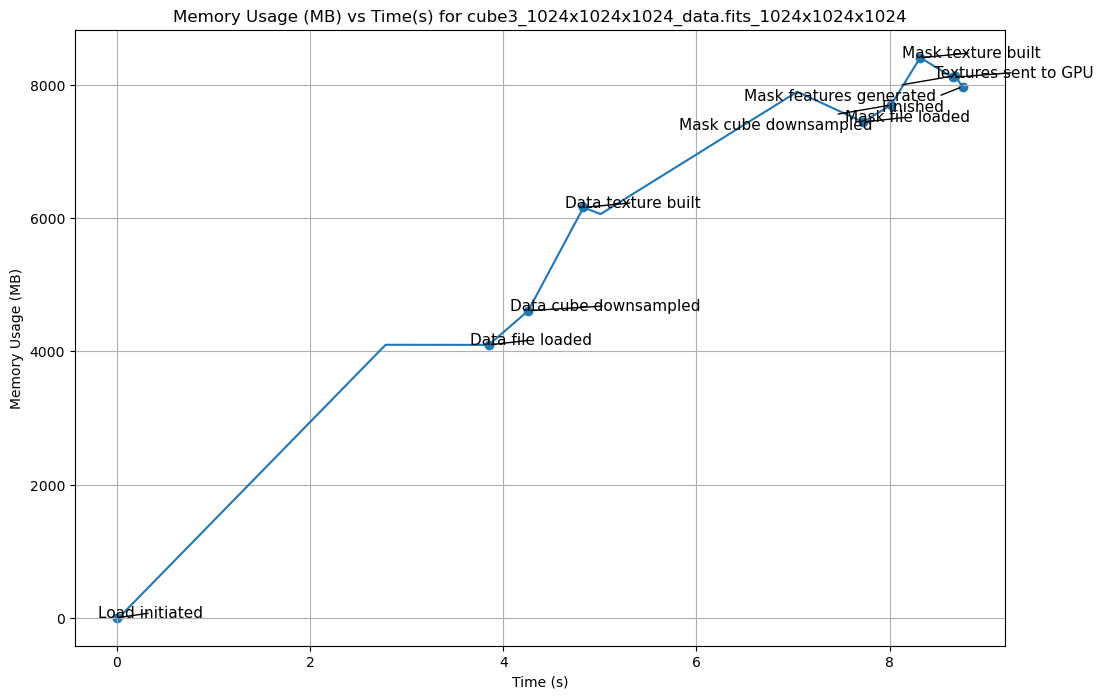

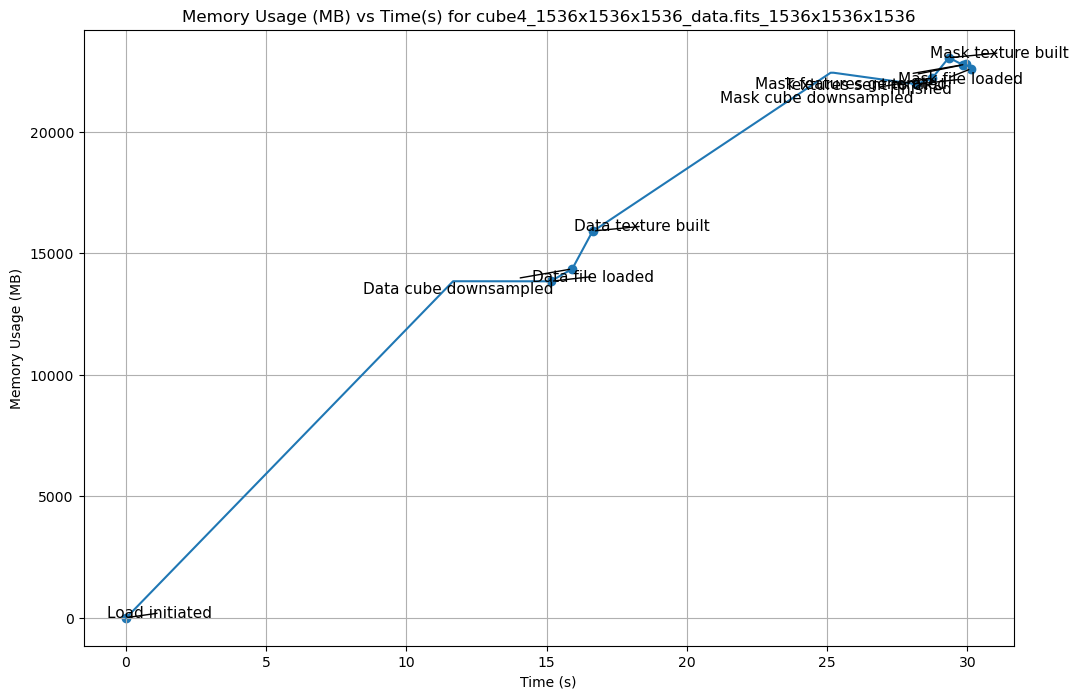

In [114]:
import matplotlib.pyplot as plt

for cube_df in merged_dfs:
    plt.figure(figsize=(12,8))
    cube_name = cube_df['Cube'].iloc[0] if 'Cube' in cube_df.columns else 'Unknown Cube'
    # Plot the line for all points (no markers)
    plt.plot(cube_df['Time(s)'], cube_df['DeltaRAM(MB)'], linestyle='-', label=cube_name)
    # Overlay markers only for non-"Update" milestones
    non_update = cube_df[~cube_df['Milestone'].astype(str).str.contains("Update")]
    plt.scatter(non_update['Time(s)'], non_update['DeltaRAM(MB)'], marker='o', color=plt.gca().lines[-1].get_color())
    
    label_positions = []

    for idx, row in non_update.iterrows():
        milestone = str(row.get('Milestone', ''))
        x_range = plt.gca().get_xlim()[1] - plt.gca().get_xlim()[0]
        y_range = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]

        # Default: top left
        label_x = row['Time(s)'] - 0.02 * x_range
        label_y = row['DeltaRAM(MB)'] + 0.02 * y_range
        ha, va = 'left', 'top'

        # Check for overlap
        overlap = any(
            abs(label_x - px) < 0.03 * x_range and abs(label_y - py) < 0.03 * y_range
            for px, py in label_positions
        )
        if overlap:
            # Try bottom left
            label_y = row['DeltaRAM(MB)'] - 0.02 * y_range
            ha, va = 'right', 'top'
            # If still overlapping, try top right
            overlap2 = any(
                abs((row['Time(s)'] + 0.02 * x_range) - px) < 0.03 * x_range and abs((row['DeltaRAM(MB)'] + 0.02 * y_range) - py) < 0.03 * y_range
                for px, py in label_positions
            )
            if overlap2:
                label_x = row['Time(s)'] + 0.02 * x_range
                label_y = row['DeltaRAM(MB)'] + 0.02 * y_range
                ha, va = 'left', 'bottom'

        label_positions.append((label_x, label_y))

        plt.annotate(
            milestone,
            xy=(row['Time(s)'], row['DeltaRAM(MB)']),
            xytext=(label_x, label_y),
            textcoords='data',
            fontsize=11,
            ha=ha,
            va=va,
            rotation=0,
            arrowprops=dict(arrowstyle='-', color='black', lw=1)
        )


    plt.ylabel('Memory Usage (MB)')
    plt.xlabel('Time (s)')
    plt.title(f'Memory Usage (MB) vs Time(s) for {cube_name}')
    plt.grid(True)
    plt.show()

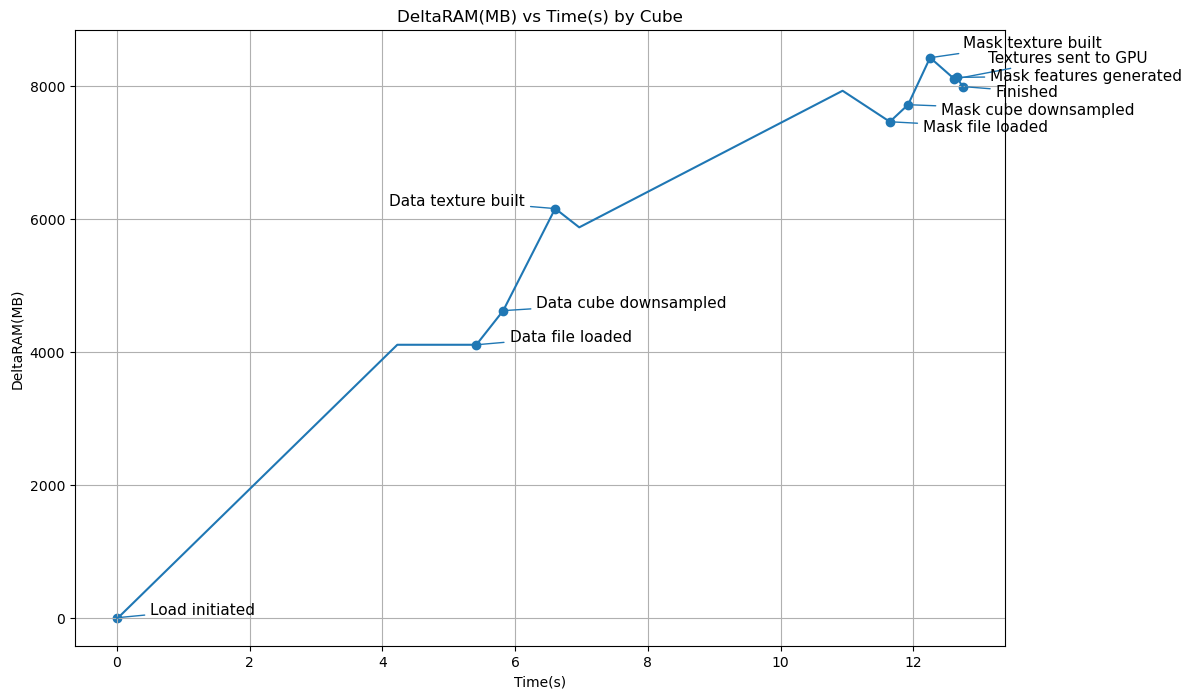

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for cube, group in merged_df.groupby('Cube'):
    # Plot the line for all points (no markers)
    plt.plot(group['Time(s)'], group['DeltaRAM(MB)'], linestyle='-', label=cube)
    # Overlay markers only for non-"Update" milestones
    non_update = group[~group['Milestone'].astype(str).str.contains("Update")]
    plt.scatter(non_update['Time(s)'], non_update['DeltaRAM(MB)'], marker='o', color=plt.gca().lines[-1].get_color())
    for idx, row in non_update.iterrows():
        milestone = str(row.get('Milestone', ''))
        # Offset label position to avoid overlap
        label_x = row['Time(s)'] + 0.5
        label_y = row['DeltaRAM(MB)'] + 10

        # Manually adjust for specific overlapping milestones
        if milestone == "Textures sent to GPU":
            label_y += 200
        elif milestone == "Mask features generated":
            label_y -= 100
        elif milestone == "Finished":
            label_y -= 200
        elif milestone == "Mask file loaded":
            label_y -= 200
        elif milestone == "Mask cube downsampled":
            label_y -= 200
        elif milestone == "Mask texture built":
            label_y += 100
        elif milestone == "Data texture built":
            label_x -= 3

        plt.annotate(
            milestone,
            xy=(row['Time(s)'], row['DeltaRAM(MB)']),
            xytext=(label_x, label_y),
            textcoords='data',
            fontsize=11,
            ha='left',
            va='bottom',
            rotation=0,
            arrowprops=dict(arrowstyle='-', color=plt.gca().lines[-1].get_color(), lw=1)
        )

plt.xlabel('Time(s)')
plt.ylabel('DeltaRAM(MB)')
plt.title('DeltaRAM(MB) vs Time(s) by Cube')
plt.grid(True)
#plt.legend(title='Cube')
plt.show()

In [125]:
import pandas as pd

df = pd.read_csv('benchmark_summary.csv')

# Example: parse dimensions from cube name, e.g. "cube_256x256x256"
def estimate_file_size_mb(cube_name):
    import re
    match = re.search(r'(\d+)x(\d+)x(\d+)', cube_name)
    if match:
        x, y, z = map(int, match.groups())
        num_voxels = x * y * z
        size_bytes = num_voxels * 4  # 4 bytes per float
        return size_bytes / (1024 * 1024)
    else:
        return None

df['FileSize(MB)'] = df['Cube'].apply(estimate_file_size_mb)

# Group by 'Cube' and calculate the mean for each column
df_avg = df.groupby('Cube', as_index=False).mean()

# Save the averaged dataframe to a new CSV
df_avg.to_csv('benchmark_summary_avg.csv', index=False)

print(df_avg)

                                            Cube    Time(s)   PeakRAM(MB)  \
0        cube1_256x256x256_data.fits_256x256x256   0.769000    867.420000   
1        cube2_512x512x512_data.fits_512x512x512   3.972667   4431.900000   
2  cube3_1024x1024x1024_data.fits_1024x1024x1024   8.458667   8407.320000   
3  cube4_1536x1536x1536_data.fits_1536x1536x1536  29.933667  22968.876667   

   FinalRAM(MB)  VRAM(MB)  FileSize(MB)  
0    867.420000      96.0          64.0  
1   4431.900000     768.0         512.0  
2   7975.333333     768.0        4096.0  
3  22585.963333     768.0       13824.0  


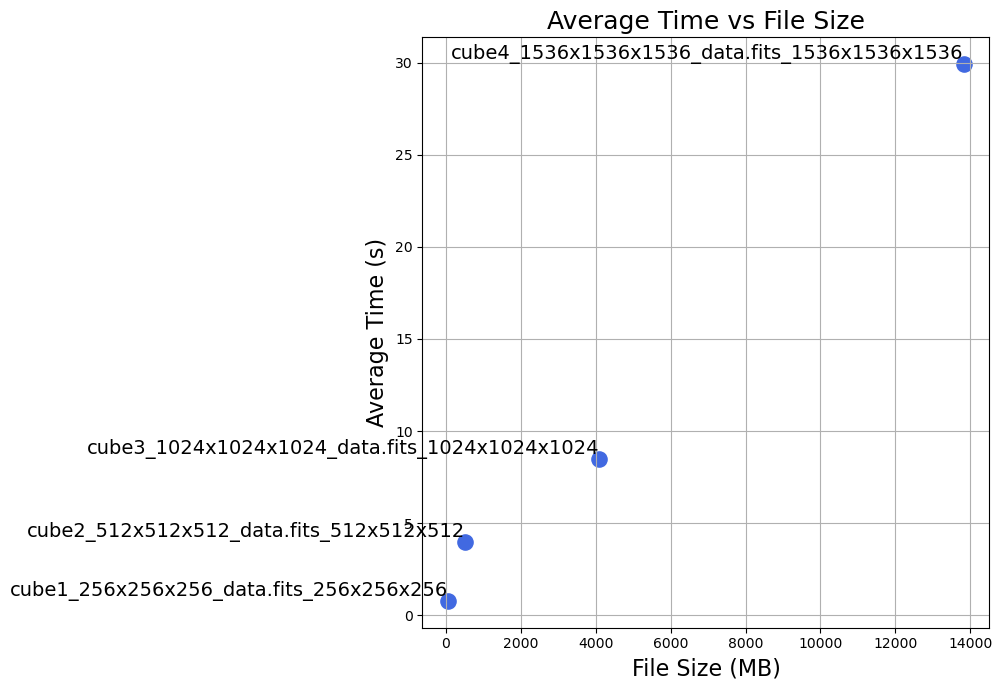

In [126]:
import matplotlib.pyplot as plt

# Assuming df_avg already has 'FileSize(MB)' and 'Time(s)' columns
plt.figure(figsize=(10,7))
plt.scatter(df_avg['FileSize(MB)'], df_avg['Time(s)'], s=120, color='royalblue')

for idx, row in df_avg.iterrows():
    plt.text(row['FileSize(MB)'], row['Time(s)'], row['Cube'], fontsize=14, ha='right', va='bottom')

plt.xlabel('File Size (MB)', fontsize=16)
plt.ylabel('Average Time (s)', fontsize=16)
plt.title('Average Time vs File Size', fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.savefig("file_size_vs_time.png", dpi=300)
plt.show()

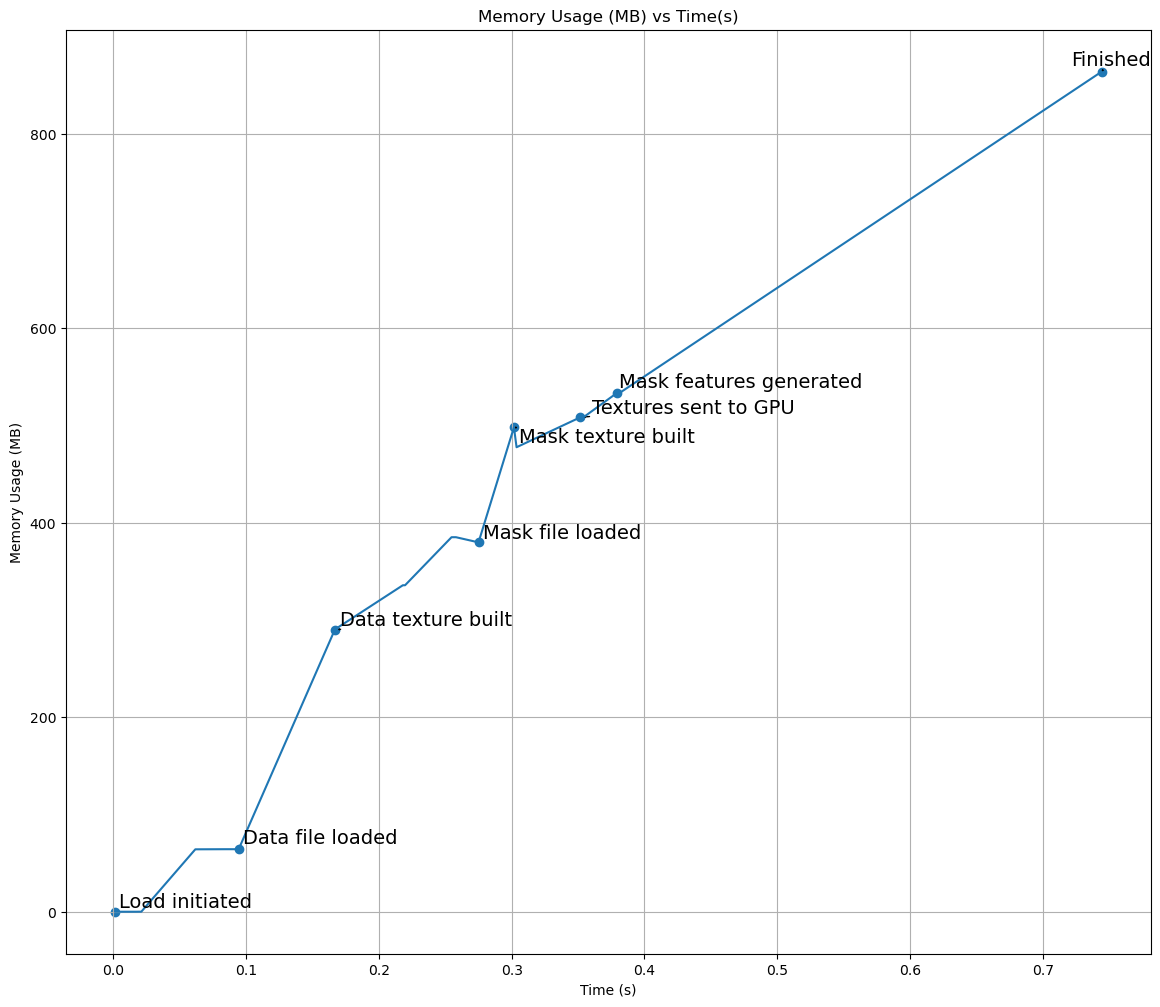

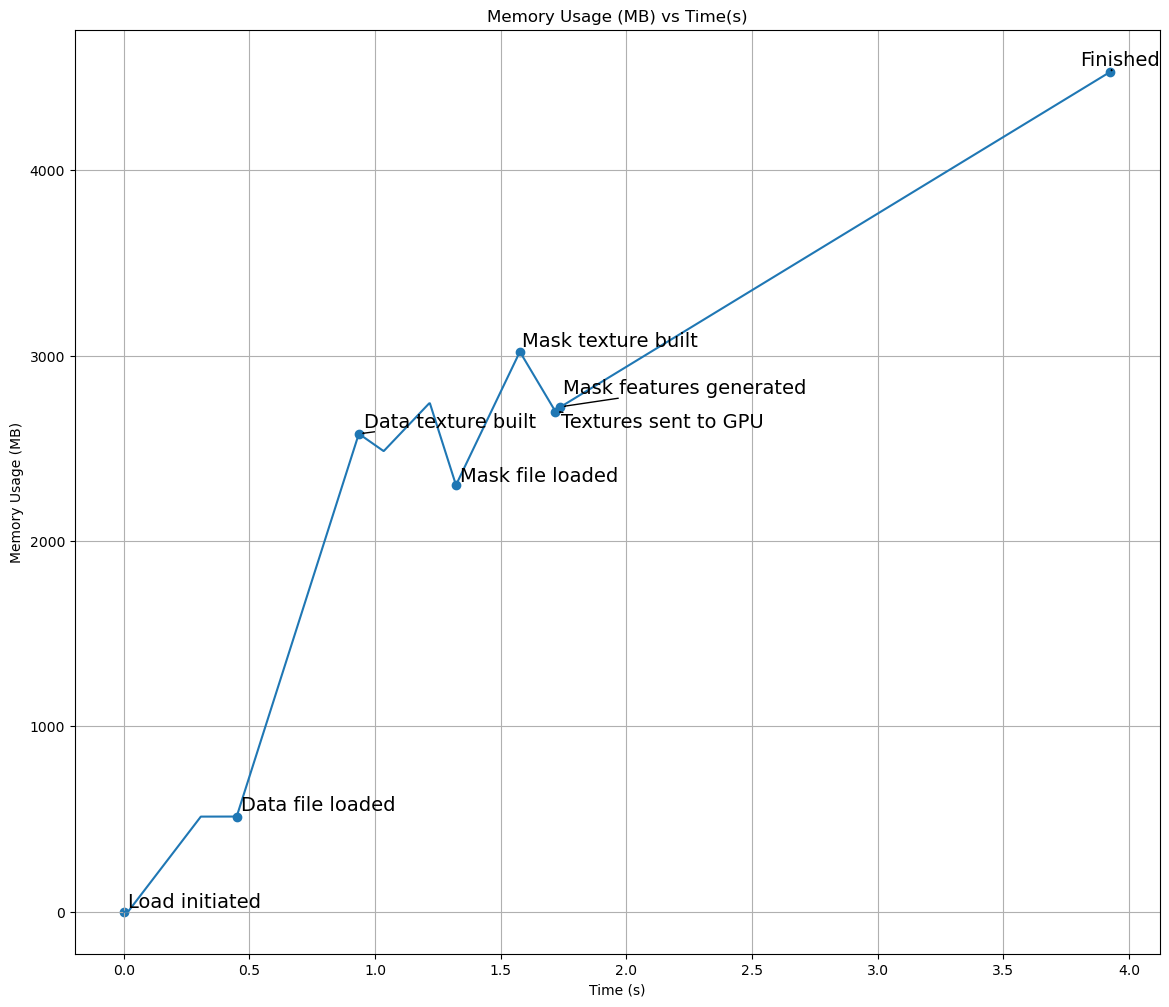

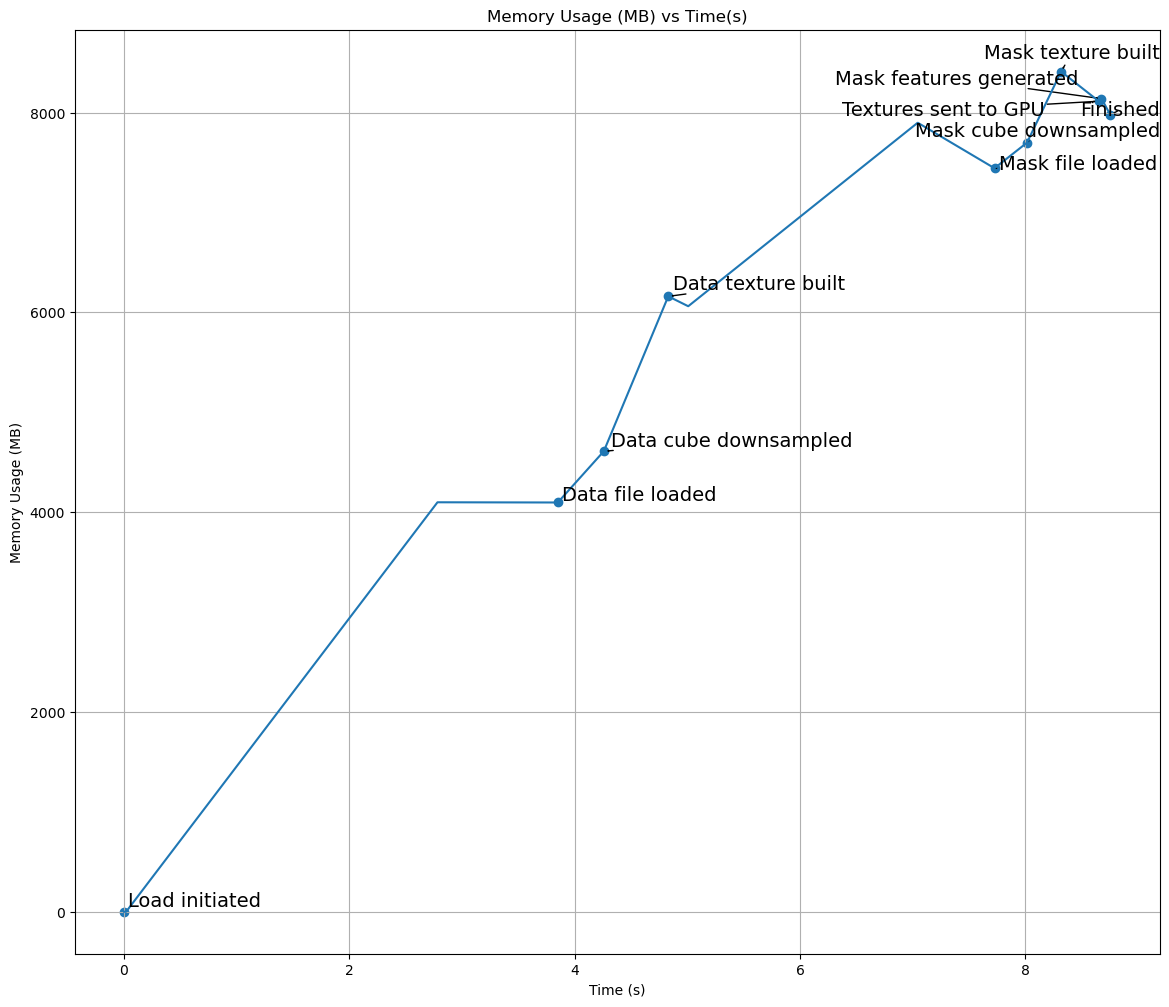

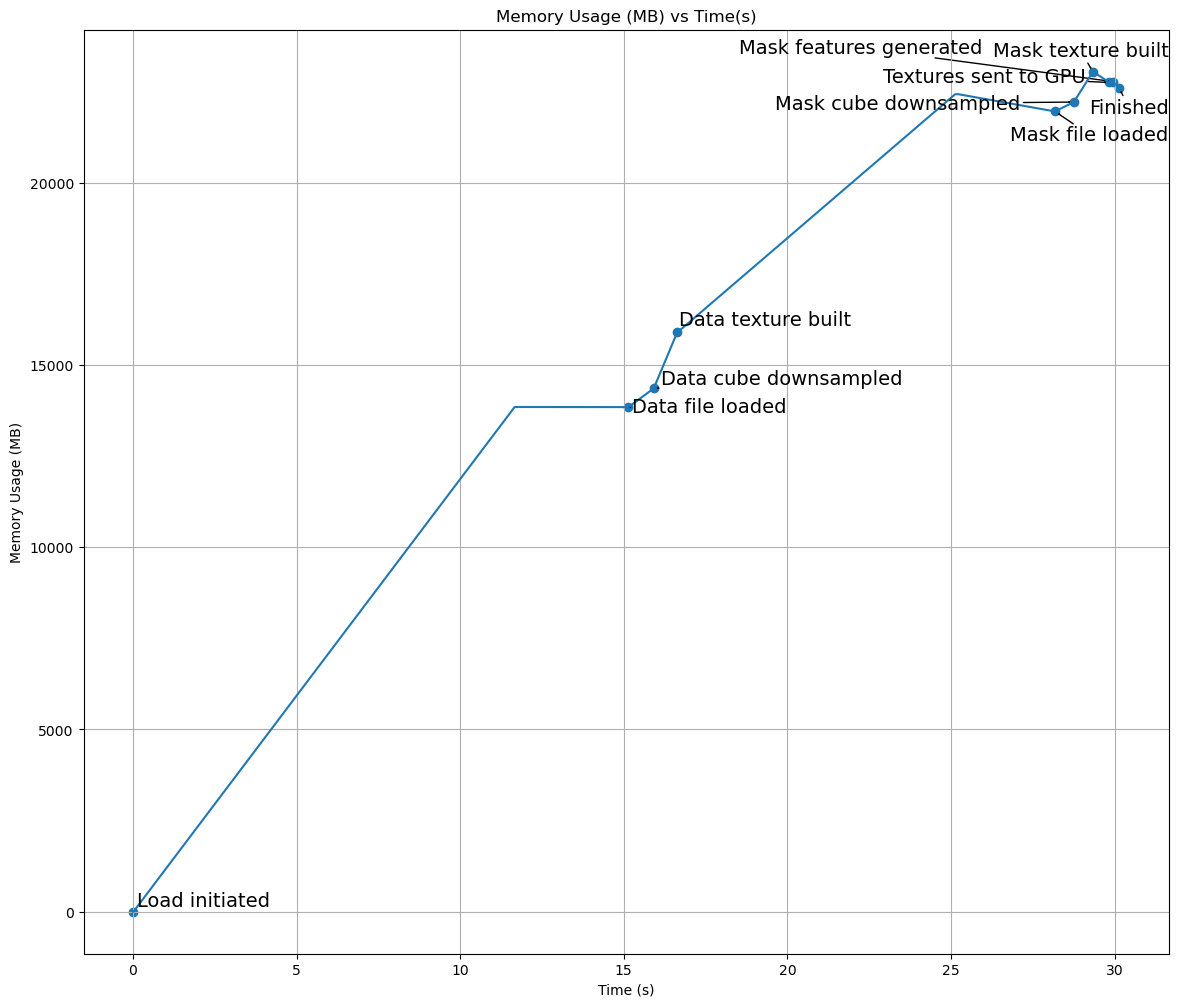

In [124]:
from adjustText import adjust_text
import matplotlib.pyplot as plt

for cube_df in merged_dfs:
    plt.figure(figsize=(14,12))
    cube_name = cube_df['Cube'].iloc[0] if 'Cube' in cube_df.columns else 'Unknown Cube'

    # Plot the line
    plt.plot(cube_df['Time(s)'], cube_df['DeltaRAM(MB)'], linestyle='-', label=cube_name)

    # Filter milestones
    non_update = cube_df[~cube_df['Milestone'].astype(str).str.contains("Update")]
    plt.scatter(non_update['Time(s)'], non_update['DeltaRAM(MB)'], marker='o', 
                color=plt.gca().lines[-1].get_color())

    texts = []
    for idx, row in non_update.iterrows():
        milestone = str(row.get('Milestone', ''))
        texts.append(
            plt.text(row['Time(s)'], row['DeltaRAM(MB)'], milestone, fontsize=14)
        )

    # Automatically adjust labels to minimize overlap
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

    plt.ylabel('Memory Usage (MB)')
    plt.xlabel('Time (s)')
    plt.title(f'Memory Usage (MB) vs Time(s)')
    plt.grid(True)
    plt.savefig(f"C:\\Users\\AlexanderSivitilli\\Documents\\GitHub\\idavie-paper\\figures\\{cube_name}_memory_usage.png", dpi=300)  # Save as PNG

    plt.show()